# EM619 - Machine Learning
## Assignment 2 - SOLUTION KEY
**Total Marks: 20** | **Questions: 5 (4 marks each)**

Numbers below were produced with `RANDOM_STATE = 42`; accept small deviations from a
different scikit-learn version.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


---
## Q1. Sigmoid, Odds & Cross-Entropy Loss (4 marks)


sigmoid(z): [0.     0.1192 0.5    0.8808 1.    ]
BCE(y=1, y_hat=0.9): 0.1054
BCE(y=1, y_hat=0.1): 2.3026


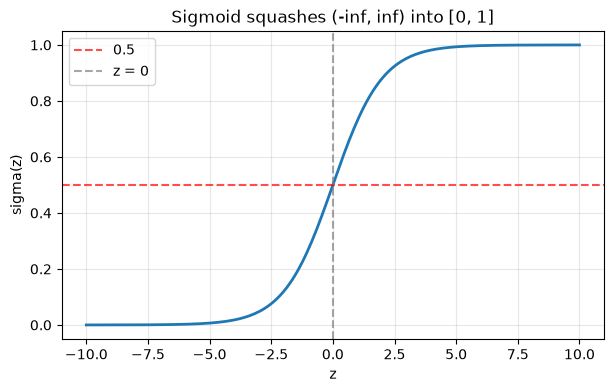

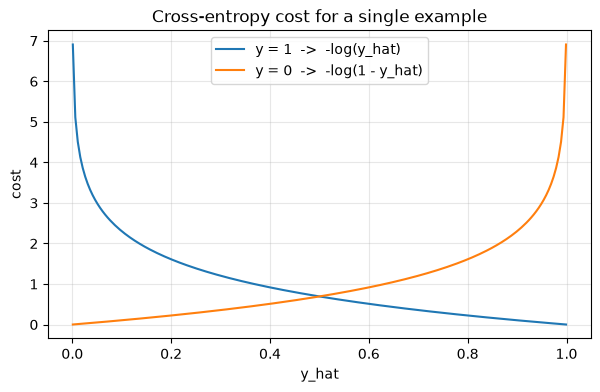

log-odds recovered: [-10.  -2.   0.   2.  10.]
original z        : [-10.  -2.   0.   2.  10.]


In [2]:
def sigmoid(z):
    '''Logistic / sigmoid function: sigma(z) = 1 / (1 + exp(-z))'''
    return 1.0 / (1.0 + np.exp(-z))


def binary_cross_entropy(y, y_hat, eps=1e-12):
    '''Mean binary cross-entropy loss.'''
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))


# --- Quick checks ---
z_check = np.array([-10.0, -2.0, 0.0, 2.0, 10.0])
print("sigmoid(z):", np.round(sigmoid(z_check), 4))
print("BCE(y=1, y_hat=0.9):", round(float(binary_cross_entropy(np.array([1.0]), np.array([0.9]))), 4))
print("BCE(y=1, y_hat=0.1):", round(float(binary_cross_entropy(np.array([1.0]), np.array([0.1]))), 4))

# Plot A: the sigmoid
z = np.linspace(-10, 10, 200)
plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid(z), lw=2)
plt.axhline(0.5, color='red', ls='--', alpha=0.7, label='0.5')
plt.axvline(0.0, color='grey', ls='--', alpha=0.7, label='z = 0')
plt.xlabel('z')
plt.ylabel('sigma(z)')
plt.title('Sigmoid squashes (-inf, inf) into [0, 1]')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot B: cross-entropy cost for a single example
y_hat_grid = np.linspace(0.001, 0.999, 200)
cost_y1 = -np.log(y_hat_grid)
cost_y0 = -np.log(1 - y_hat_grid)

plt.figure(figsize=(7, 4))
plt.plot(y_hat_grid, cost_y1, label='y = 1  ->  -log(y_hat)')
plt.plot(y_hat_grid, cost_y0, label='y = 0  ->  -log(1 - y_hat)')
plt.xlabel('y_hat')
plt.ylabel('cost')
plt.title('Cross-entropy cost for a single example')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Log-odds identity: log(p / (1 - p)) == z
p = sigmoid(z_check)
print("log-odds recovered:", np.round(np.log(p / (1 - p)), 4))
print("original z        :", z_check)


### Observations (Q1) - reference answer
- `sigmoid(0) = 0.5`, so the boundary sits where $\sigma(X\theta) = 0.5$, i.e. at $X\theta = 0$ - a linear boundary in feature space.
- The cost $-\log\hat{y}$ diverges as $\hat{y} \to 0$: the printout gives 0.1054 at $\hat{y} = 0.9$ against 2.3026 at $\hat{y} = 0.1$. Confidently wrong predictions are punished far harder than merely uncertain ones, which is what pushes training away from them.
- Squared error composed with the sigmoid is non-convex - multiple local minima, so gradient descent has no guarantee of finding the global optimum. Cross-entropy is the negative log-likelihood of the Bernoulli model and is convex in $\theta$.
- The log-odds check returns `z` exactly, confirming $\log\frac{P(y=1|X)}{P(y=0|X)} = X\theta$: logistic regression is linear in log-odds, not in probability.


---
## Q2. Logistic Regression from Scratch - Gradient Descent (4 marks)
Dataset: `load_breast_cancer()`.


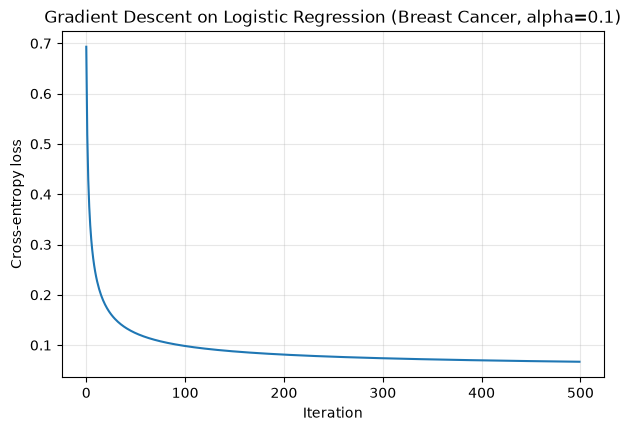

Manual GD  -> train acc: 0.9849 | test acc: 0.9766
Final training loss: 0.0670  (started at 0.6931)
sklearn    -> test acc: 0.9825
Max |theta_manual - theta_sklearn|: 0.6642


In [3]:
def logistic_gd(X, y, alpha=0.1, n_iters=500):
    '''Batch gradient descent for logistic regression. Returns theta, loss_history.'''
    m, n = X.shape
    theta = np.zeros(n)
    loss_history = []

    for _ in range(n_iters):
        y_hat = sigmoid(X @ theta)
        gradient = (1 / m) * (X.T @ (y_hat - y))
        theta = theta - alpha * gradient
        loss_history.append(binary_cross_entropy(y, y_hat))

    return theta, loss_history


def predict_labels(X, theta, threshold=0.5):
    '''Return 0/1 predictions.'''
    return (sigmoid(X @ theta) >= threshold).astype(int)


# --- Data setup ---
cancer = load_breast_cancer()
Xb, yb = cancer.data, cancer.target
Xb = StandardScaler().fit_transform(Xb)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.3, random_state=RANDOM_STATE, stratify=yb
)
Xb_train_bias = np.hstack([np.ones((Xb_train.shape[0], 1)), Xb_train])
Xb_test_bias = np.hstack([np.ones((Xb_test.shape[0], 1)), Xb_test])

theta, loss_history = logistic_gd(Xb_train_bias, yb_train, alpha=0.1, n_iters=500)

plt.figure(figsize=(7, 4.5))
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Cross-entropy loss')
plt.title('Gradient Descent on Logistic Regression (Breast Cancer, alpha=0.1)')
plt.grid(alpha=0.3)
plt.show()

train_acc = accuracy_score(yb_train, predict_labels(Xb_train_bias, theta))
test_acc = accuracy_score(yb_test, predict_labels(Xb_test_bias, theta))
print(f"Manual GD  -> train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")
print(f"Final training loss: {loss_history[-1]:.4f}  (started at {loss_history[0]:.4f})")

sk_model = LogisticRegression(max_iter=5000)
sk_model.fit(Xb_train, yb_train)
sk_acc = accuracy_score(yb_test, sk_model.predict(Xb_test))
print(f"sklearn    -> test acc: {sk_acc:.4f}")
print("Max |theta_manual - theta_sklearn|:",
      round(float(np.max(np.abs(theta[1:] - sk_model.coef_.ravel()))), 4))


### Observations (Q2) - reference answer
- The loss falls from 0.6931 ($= \log 2$, the loss of a model that predicts 0.5 everywhere) to 0.0670, smoothly and monotonically. That is the signature of a convex surface: cross-entropy has one global minimum, so gradient descent reaches it from any start.
- Manual GD gets 0.9849 train / 0.9766 test; sklearn gets 0.9825 test - one test sample out of 171 apart. Coefficients differ by up to 0.66 because sklearn applies L2 regularisation by default (`C=1.0`) and runs lbfgs to convergence, while our unregularised GD takes 500 fixed-size steps.
- Setting $X^{\top}(\sigma(X\theta) - y) = 0$ gives a transcendental system - $\theta$ sits inside the sigmoid and cannot be isolated the way $(X^{\top}X)^{-1}X^{\top}y$ isolates it. Hence gradient descent, or second-order methods like Newton / IRLS.


---
## Q3. Decision Boundary & Feature Transformation (4 marks)
Dataset: `make_circles()`.


(a) Raw features [x1, x2]        -> test accuracy: 0.5333


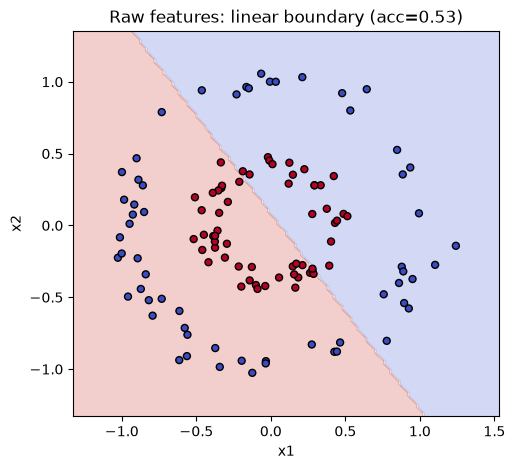

(b) With x1^2, x2^2 added        -> test accuracy: 1.0000


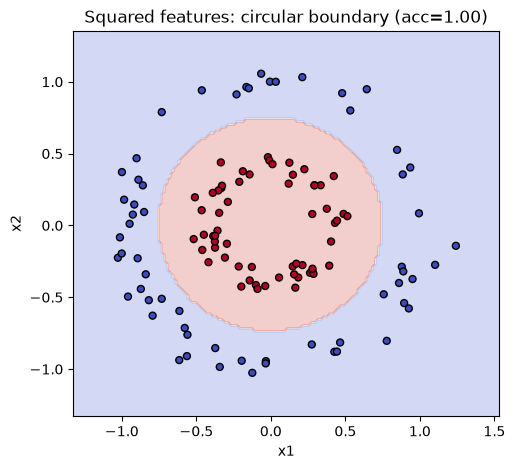

(c) C=0.01   -> test accuracy: 1.0000 | coef_: [[-0.024 -0.017 -0.26  -0.282]]
(c) C=100    -> test accuracy: 1.0000 | coef_: [[ -0.266   0.297 -16.349 -17.108]]


In [4]:
def add_squared_features(X):
    '''[x1, x2] -> [x1, x2, x1^2, x2^2]'''
    return np.column_stack([X[:, 0], X[:, 1], X[:, 0] ** 2, X[:, 1] ** 2])


# --- Data setup and plotting helper (do not modify) ---
Xc, yc = make_circles(n_samples=400, noise=0.08, factor=0.4, random_state=RANDOM_STATE)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.3, random_state=RANDOM_STATE, stratify=yc
)


def plot_decision_boundary(model, X, y, title, transform=None):
    '''Shade the region the model predicts as class 1, then scatter the data on top.'''
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if transform is not None:
        grid = transform(grid)
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(5.5, 5))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=25)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.show()


# (a) Raw features - linear boundary
model_raw = LogisticRegression()
model_raw.fit(Xc_train, yc_train)
acc_raw = accuracy_score(yc_test, model_raw.predict(Xc_test))
print(f"(a) Raw features [x1, x2]        -> test accuracy: {acc_raw:.4f}")
plot_decision_boundary(model_raw, Xc_test, yc_test,
                       f'Raw features: linear boundary (acc={acc_raw:.2f})')

# (b) With squared features
Xc_train_poly = add_squared_features(Xc_train)
Xc_test_poly = add_squared_features(Xc_test)

model_poly = LogisticRegression()
model_poly.fit(Xc_train_poly, yc_train)
acc_poly = accuracy_score(yc_test, model_poly.predict(Xc_test_poly))
print(f"(b) With x1^2, x2^2 added        -> test accuracy: {acc_poly:.4f}")
plot_decision_boundary(model_poly, Xc_test, yc_test,
                       f'Squared features: circular boundary (acc={acc_poly:.2f})',
                       transform=add_squared_features)

# (c) Effect of the L2 penalty (C = 1 / lambda)
for C in [0.01, 100]:
    m = LogisticRegression(C=C)
    m.fit(Xc_train_poly, yc_train)
    acc_c = accuracy_score(yc_test, m.predict(Xc_test_poly))
    print(f"(c) C={C:<6} -> test accuracy: {acc_c:.4f} | coef_: {np.round(m.coef_, 3)}")


### Observations (Q3) - reference answer
- Raw features give 0.5333 - a coin flip, since the rings share a centre and any straight line splits both classes in half. Adding $x_1^2, x_2^2$ gives 1.0000. This is bias (underfitting): straight lines cannot express the true boundary, so more data would not help.
- The boundary is a circle in the $(x_1, x_2)$ plane, but the model still solves $\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 + \theta_4 x_2^2 = 0$ - a hyperplane in the transformed 4-D space. The curvature comes from the feature map, not the model.
- `C=100` leaves large coefficients on the squared terms (`[-0.266, 0.297, -16.349, -17.108]`); `C=0.01` shrinks everything towards zero (`[-0.024, -0.017, -0.260, -0.282]`), about 60x smaller. Shrinkage guards against overfitting by stopping one feature from dominating. Both are perfect on these clean rings, so `C` would be chosen by cross-validation on noisier data.


---
## Q4. Multi-Class - Softmax vs One-vs-Rest (4 marks)
Dataset: `load_iris()`.


softmax(scores): [0.659  0.2424 0.0986] | sums to: 1.0
softmax([0, z])[1] = 0.785835
sigmoid(z)         = 0.785835


Multinomial (softmax) -> test accuracy: 0.9333 | coef_ shape: (3, 4)
One-vs-Rest           -> test accuracy: 0.8889 | 3 separate binary models

First test sample probabilities: [0.     0.0323 0.9677] | sum = 1.0 | predicted: virginica | true: virginica


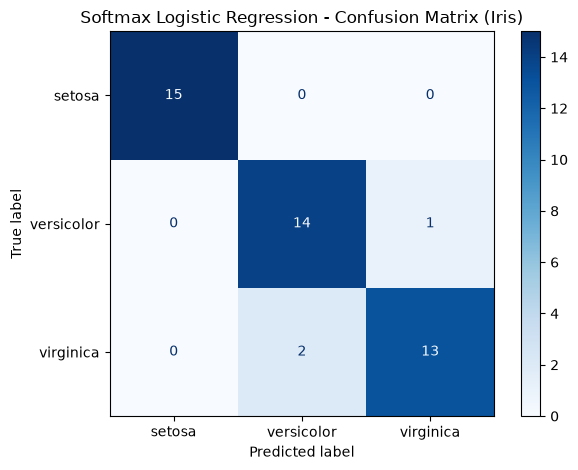

In [5]:
def softmax(z):
    '''Numerically stable softmax for a 1-D score vector.'''
    e = np.exp(z - np.max(z))
    return e / np.sum(e)


# --- Quick checks ---
scores = np.array([2.0, 1.0, 0.1])
probs = softmax(scores)
print("softmax(scores):", np.round(probs, 4), "| sums to:", round(float(np.sum(probs)), 6))

z_test = 1.3
print("softmax([0, z])[1] =", round(float(softmax(np.array([0.0, z_test]))[1]), 6))
print("sigmoid(z)         =", round(float(sigmoid(z_test)), 6))

# --- Data setup ---
iris = load_iris()
Xi, yi = iris.data, iris.target
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    Xi, yi, test_size=0.3, random_state=RANDOM_STATE, stratify=yi
)

# Multinomial (softmax) logistic regression
model_softmax = LogisticRegression(max_iter=1000)
model_softmax.fit(Xi_train, yi_train)
acc_softmax = accuracy_score(yi_test, model_softmax.predict(Xi_test))
print(f"Multinomial (softmax) -> test accuracy: {acc_softmax:.4f} | coef_ shape: {model_softmax.coef_.shape}")

# One-vs-Rest
model_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model_ovr.fit(Xi_train, yi_train)
acc_ovr = accuracy_score(yi_test, model_ovr.predict(Xi_test))
print(f"One-vs-Rest           -> test accuracy: {acc_ovr:.4f} | 3 separate binary models")

first_probs = model_softmax.predict_proba(Xi_test[:1])[0]
print("\nFirst test sample probabilities:", np.round(first_probs, 4),
      "| sum =", round(float(first_probs.sum()), 6),
      "| predicted:", iris.target_names[np.argmax(first_probs)],
      "| true:", iris.target_names[yi_test[0]])

ConfusionMatrixDisplay.from_estimator(model_softmax, Xi_test, yi_test,
                                      display_labels=iris.target_names, cmap='Blues')
plt.title('Softmax Logistic Regression - Confusion Matrix (Iris)')
plt.tight_layout()
plt.show()


### Observations (Q4) - reference answer
- Softmax guarantees outputs in $[0,1]$ that sum to 1, i.e. a valid distribution over classes: `[0.6590, 0.2424, 0.0986]` sums to 1.0. The $K=2$ check gives `softmax([0, 1.3])[1] = 0.785835 = sigmoid(1.3)`, so binary logistic regression is just the two-class case of softmax regression.
- `coef_.shape` is (3, 4): one weight vector per class, each of length 4. Multinomial fits all three jointly through a shared softmax denominator; one-vs-rest trains 3 independent binary classifiers and takes the arg-max of their unnormalised scores. Multinomial scores 0.9333 against OvR's 0.8889 (42 vs 40 of 45), which is why it is sklearn's default.
- Setosa is classified perfectly; all 3 errors are versicolor / virginica confusions. Setosa is linearly separable from the other two, while versicolor and virginica overlap in petal measurements.


---
## Q5. Class Imbalance - Metrics & Threshold Tuning (4 marks)
Dataset: synthetic imbalanced data via `make_classification` (~5% positives).


Train class counts: [2660  140] | positives: 5.00%

plain                  acc=0.9792 | precision=0.9070 | recall=0.6500 | f1=0.7573
confusion matrix [[TN FP], [FN TP]]:
 [[1136    4]
 [  21   39]]

class_weight=balanced  acc=0.9342 | precision=0.4228 | recall=0.8667 | f1=0.5683
confusion matrix [[TN FP], [FN TP]]:
 [[1069   71]
 [   8   52]]


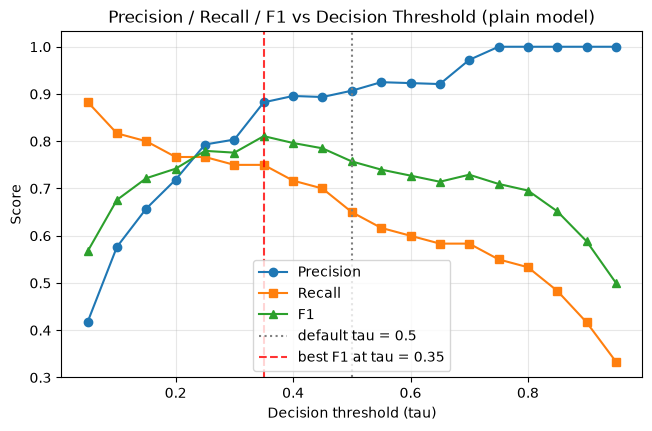


Best threshold by F1: tau = 0.35 (F1 = 0.8108) vs F1 = 0.7573 at the default tau = 0.5
ROC-AUC plain          : 0.9562
ROC-AUC balanced       : 0.9575


In [6]:
def evaluate(y_true, y_pred, label):
    '''Print accuracy, precision, recall and F1.'''
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"{label:<22} acc={acc:.4f} | precision={prec:.4f} | recall={rec:.4f} | f1={f1:.4f}")


def metrics_vs_threshold(model, X_test, y_test, thresholds):
    '''Precision / recall / F1 at each decision threshold.'''
    probs = model.predict_proba(X_test)[:, 1]
    precisions, recalls, f1s = [], [], []

    for tau in thresholds:
        y_pred = (probs >= tau).astype(int)
        precisions.append(precision_score(y_test, y_pred, zero_division=0))
        recalls.append(recall_score(y_test, y_pred, zero_division=0))
        f1s.append(f1_score(y_test, y_pred, zero_division=0))

    return precisions, recalls, f1s


# --- Data setup ---
X_imb, y_imb = make_classification(
    n_samples=4000, n_features=8, n_informative=4, n_redundant=0,
    weights=[0.95, 0.05], flip_y=0.0, class_sep=2.5, random_state=RANDOM_STATE
)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=RANDOM_STATE, stratify=y_imb
)
print("Train class counts:", np.bincount(ym_train),
      f"| positives: {100 * ym_train.mean():.2f}%")

# (a) Plain logistic regression
model_plain = LogisticRegression(max_iter=1000)
model_plain.fit(Xm_train, ym_train)
pred_plain = model_plain.predict(Xm_test)
print()
evaluate(ym_test, pred_plain, "plain")
print("confusion matrix [[TN FP], [FN TP]]:\n", confusion_matrix(ym_test, pred_plain))

# (b) Weighted loss
model_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
model_bal.fit(Xm_train, ym_train)
pred_bal = model_bal.predict(Xm_test)
print()
evaluate(ym_test, pred_bal, "class_weight=balanced")
print("confusion matrix [[TN FP], [FN TP]]:\n", confusion_matrix(ym_test, pred_bal))

# (c) Threshold tuning on the plain model
thresholds = np.linspace(0.05, 0.95, 19)
precisions, recalls, f1s = metrics_vs_threshold(model_plain, Xm_test, ym_test, thresholds)

best_idx = int(np.argmax(f1s))
best_tau = thresholds[best_idx]

plt.figure(figsize=(7.5, 4.5))
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='s', label='Recall')
plt.plot(thresholds, f1s, marker='^', label='F1')
plt.axvline(0.5, color='grey', ls=':', label='default tau = 0.5')
plt.axvline(best_tau, color='red', ls='--', alpha=0.8, label=f'best F1 at tau = {best_tau:.2f}')
plt.xlabel('Decision threshold (tau)')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Decision Threshold (plain model)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"\nBest threshold by F1: tau = {best_tau:.2f} (F1 = {f1s[best_idx]:.4f}) "
      f"vs F1 = {f1_score(ym_test, pred_plain):.4f} at the default tau = 0.5")
print("ROC-AUC plain          :", round(roc_auc_score(ym_test, model_plain.predict_proba(Xm_test)[:, 1]), 4))
print("ROC-AUC balanced       :", round(roc_auc_score(ym_test, model_bal.predict_proba(Xm_test)[:, 1]), 4))


### Observations (Q5) - reference answer
- Accuracy is 0.9792 but recall is only 0.6500: the matrix `[[1136, 4], [21, 39]]` shows 21 of 60 positives missed. A classifier that always predicted "negative" would already score 0.95, so accuracy barely separates a useful model from a useless one - the accuracy paradox.
- `class_weight='balanced'` puts $w_k = N/(K N_k)$ in front of each cross-entropy term, here making a minority mistake cost about 19x a majority one. Recall rises to 0.8667 (8 missed instead of 21) but precision falls from 0.9070 to 0.4228 (71 false positives instead of 4), and accuracy dips to 0.9342.
- The best-F1 threshold is $\tau = 0.35$, below the default, lifting F1 from 0.7573 to 0.8108. With only 5% positives the fitted probabilities are squeezed towards 0, so genuine positives land in the 0.3-0.5 band and never cross 0.5. Lowering $\tau$ recovers them without retraining.
- ROC-AUC is nearly identical (0.9562 vs 0.9575): reweighting changes the operating point, not the ranking. ROC-AUC therefore says the scores are informative but not which cut-off to deploy - that needs the precision-recall curve and the cost of a false negative versus a false positive.
